<a href="https://colab.research.google.com/github/jaofe/Meta-Learning/blob/main/MetaLearning_Ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Install libraries

In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn imblearn

# 2. Library Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Classification algorithms
#from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
#from sklearn.svm import SVC
#from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import f1_score, accuracy_score, make_scorer
from imblearn.metrics import geometric_mean_score

#warnings.filterwarnings('ignore')

# 3. Dataset Import

In [ ]:

# Loading the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Dataset shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget class names:", data.target_names)

Dataset shape: (569, 30)

Target distribution:
target
1    357
0    212
Name: count, dtype: int64

Target class names: ['malignant' 'benign']


In [ ]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

# 4. Data preprocessing

In [ ]:
# Check for missing values
print("Missing values:", X.isnull().sum().sum())

Missing values: 0


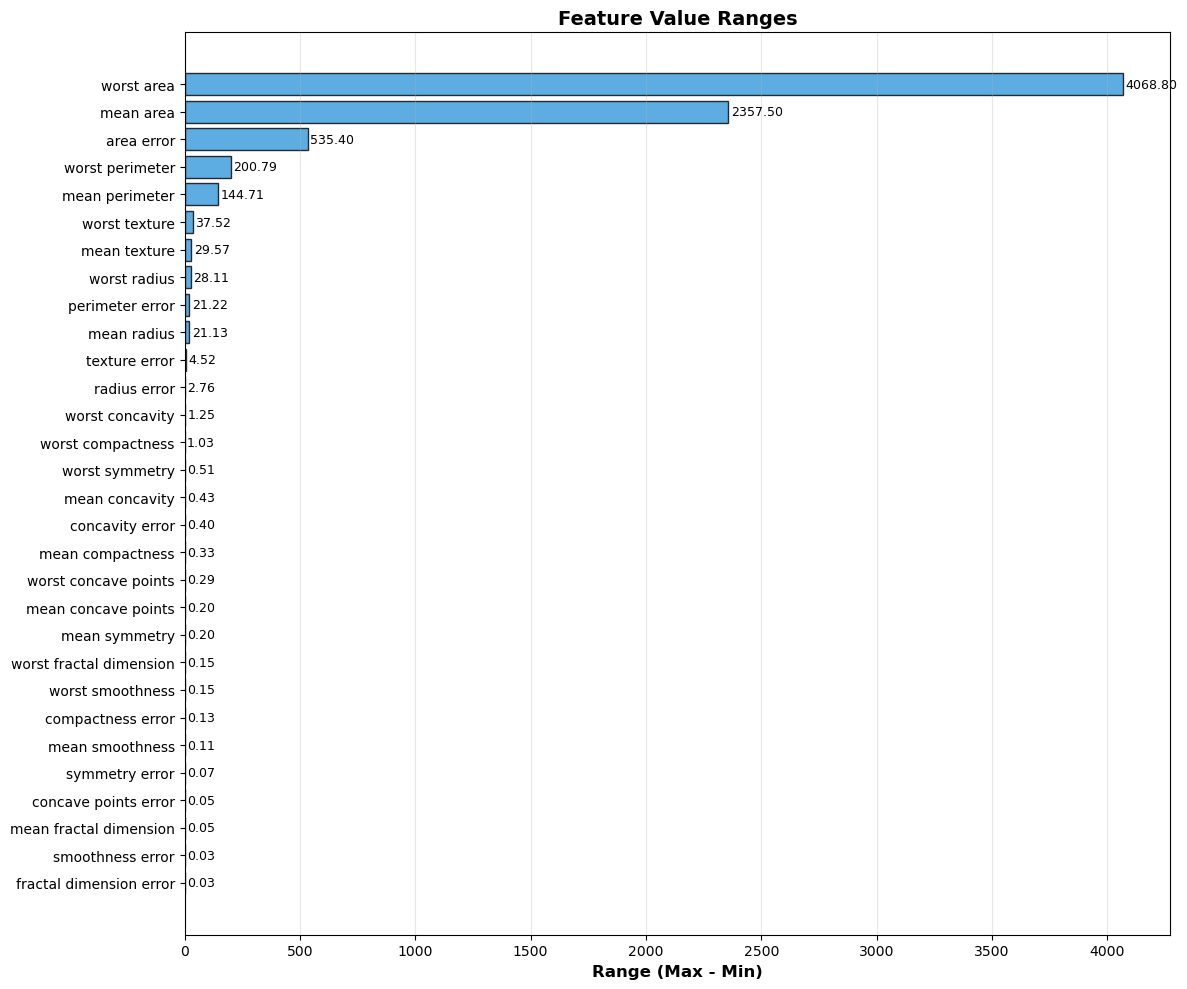

In [ ]:
# Check feature scaling

# Calculate min and max for each feature
feature_ranges = pd.DataFrame({
    'Feature': X.columns,
    'Min': X.min().values,
    'Max': X.max().values,
    'Range': (X.max() - X.min()).values
})

# Sort by range in descending order
feature_ranges = feature_ranges.sort_values('Range', ascending=True)

# Create barplot
fig, ax = plt.subplots(figsize=(12, 10))

y_pos = np.arange(len(feature_ranges))
ax.barh(y_pos, feature_ranges['Range'], color='#3498db', alpha=0.8, edgecolor='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(feature_ranges['Feature'])
ax.set_xlabel('Range (Max - Min)', fontsize=12, fontweight='bold')
ax.set_title('Feature Value Ranges', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(feature_ranges.iterrows()):
    ax.text(row['Range'] + 10, i, f"{row['Range']:.2f}", va='center', fontsize=9)

plt.tight_layout()
#plt.savefig('feature_ranges.png', dpi=150, bbox_inches='tight')
plt.show()

#print("Feature Range Analysis:")
#print(feature_ranges.to_string(index=False))

We will need to apply feature scaling from within the 5-fold CV loop.

# 5. Model Training with 5-Fold Cross Validation


In [ ]:
# Initialize Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Import RobustScaler
from sklearn.preprocessing import RobustScaler

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results for each fold
accuracies = []
f1_scores = []
gmeans = []
train_times = []
test_times = []
feature_importances_list = []

print("Running 5-Fold Cross Validation with Random Forest...\n")

for fold_num, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Apply RobustScaler to training data
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train and evaluate
    start_time = time()
    clf.fit(X_train_scaled, y_train)
    train_time = time() - start_time

    # Store feature importances for this fold
    feature_importances_list.append(clf.feature_importances_)

    start_time = time()
    y_pred = clf.predict(X_test_scaled)
    test_time = time() - start_time

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    gmean = geometric_mean_score(y_test, y_pred, average='weighted')

    accuracies.append(acc)
    f1_scores.append(f1)
    gmeans.append(gmean)
    train_times.append(train_time)
    test_times.append(test_time)

    # print(f"Fold {fold_num}:")
    # print(f"  Accuracy: {acc:.4f}")
    # print(f"  F1-Score: {f1:.4f}")
    # print(f"  G-Mean:   {gmean:.4f}")
    # print()

# Calculate mean feature importances across folds
mean_feature_importances = np.mean(feature_importances_list, axis=0)
std_feature_importances = np.std(feature_importances_list, axis=0)

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean Importance': mean_feature_importances,
    'Std Importance': std_feature_importances
}).sort_values('Mean Importance', ascending=False)

# print("=" * 80)
# print("MEAN FEATURE IMPORTANCES (Across 5 Folds)")
# print("=" * 80)
# print(feature_importance_df.to_string(index=False))
# print()

# # Aggregate results
# results = {
#     'Classifier': ['Random Forest'],
#     'Accuracy (mean)': [np.mean(accuracies)],
#     'Accuracy (std)': [np.std(accuracies)],
#     'F1-Score (mean)': [np.mean(f1_scores)],
#     'F1-Score (std)': [np.std(f1_scores)],
#     'G-Mean (mean)': [np.mean(gmeans)],
#     'G-Mean (std)': [np.std(gmeans)],
#     'Train Time (s)': [np.mean(train_times)],
#     'Test Time (s)': [np.mean(test_times)]
# }

print("=" * 60)
print("CROSS-VALIDATION SUMMARY")
print("=" * 60)
print(f"Accuracy: {np.mean(accuracies):.4f} (+/- {np.std(accuracies):.4f})")
print(f"F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")
print(f"G-Mean:   {np.mean(gmeans):.4f} (+/- {np.std(gmeans):.4f})")
print(f"Avg Train Time: {np.mean(train_times):.6f}s")
print(f"Avg Test Time:  {np.mean(test_times):.6f}s")

Running 5-Fold Cross Validation with Random Forest...

CROSS-VALIDATION SUMMARY
Accuracy: 0.9561 (+/- 0.0123)
F1-Score: 0.9560 (+/- 0.0125)
G-Mean:   0.9526 (+/- 0.0170)
Avg Train Time: 0.168417s
Avg Test Time:  0.006244s


In [ ]:
feature_importance_df

,Feature,Mean Importance,Std Importance
23,worst area,0.158870,0.019779
27,worst concave points,0.124576,0.006955
7,mean concave points,0.095846,0.020713
22,worst perimeter,0.090661,0.012187
2,mean perimeter,0.076249,0.010363
20,worst radius,0.071512,0.005836
6,mean concavity,0.058122,0.013637
3,mean area,0.050413,0.008376
0,mean radius,0.044680,0.007172
13,area error,0.034147,0.005583


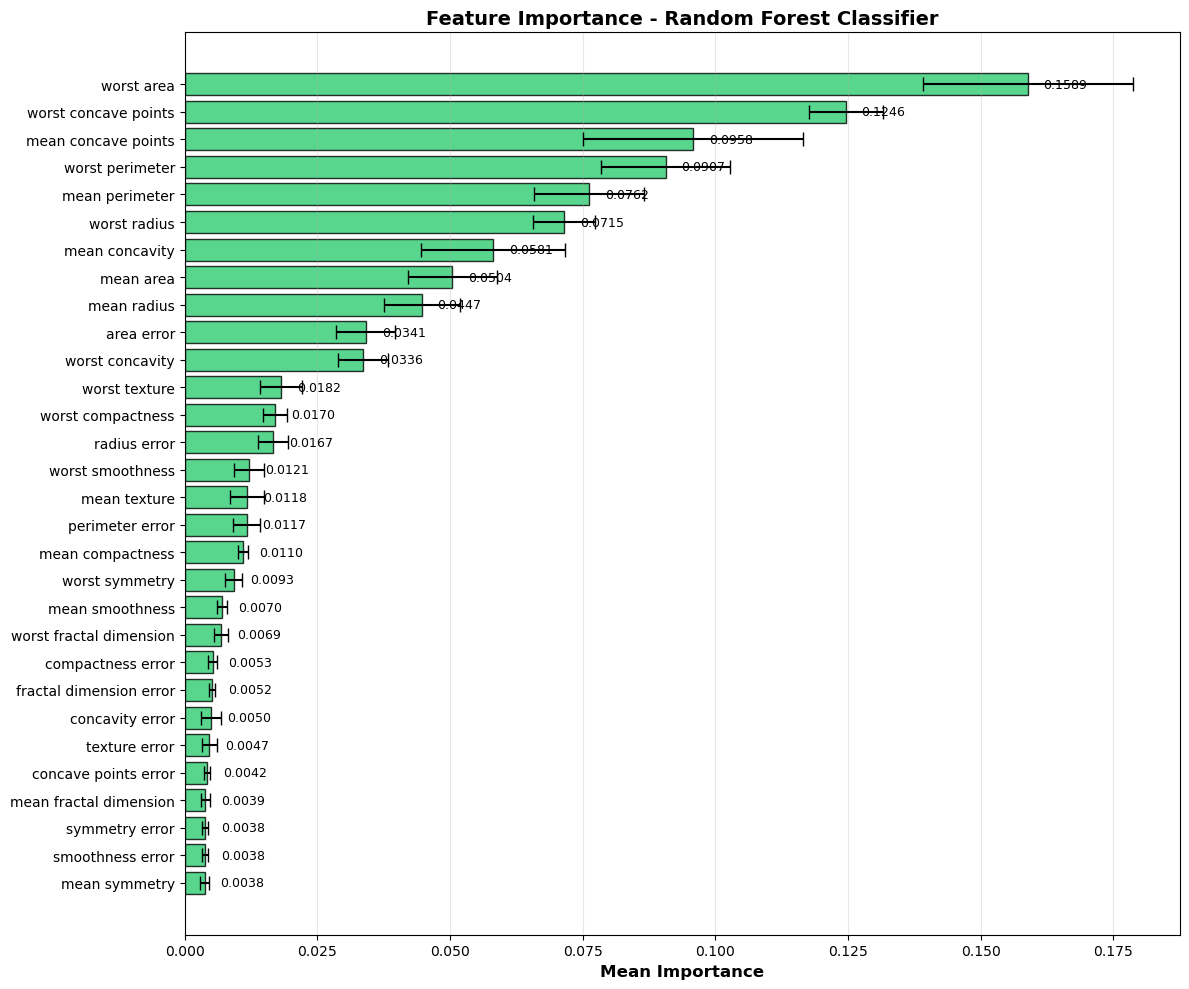

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

y_pos = np.arange(len(feature_importance_df))
ax.barh(y_pos, feature_importance_df['Mean Importance'],
    xerr=feature_importance_df['Std Importance'],
    color='#2ecc71', alpha=0.8, edgecolor='black', capsize=5)

ax.set_yticks(y_pos)
ax.set_yticklabels(feature_importance_df['Feature'])
ax.set_xlabel('Mean Importance', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance - Random Forest Classifier', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Add value labels on bars
for i, (idx, row) in enumerate(feature_importance_df.iterrows()):
    ax.text(row['Mean Importance'] + 0.003, i, f"{row['Mean Importance']:.4f}",
        va='center', fontsize=9)

plt.tight_layout()
#plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Using a Neural Network to get a better F1-Score

In [ ]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/351.2 MB 7.1 MB/s eta 0:00:50
   ---------------------------------------- 2.1/351.2 MB 6.3 MB/s eta 0:00:56
   ---------------------------------------- 3.7/351.2 MB 6.9 MB/s eta 0:00:51
    --------------------------------------- 5.2/351.2 MB 7.4 MB/s eta 0:00:47
    --------------------------------------- 6.8/351.2 MB 7.3 MB/s eta 0:00:48
    --------------------------------------- 8.1/351.2 MB 7.2 MB/s eta 0:00:48
   - -------------------------------------- 9.4/351.2 MB 7.1 MB/s eta 0:00:49
   - -------------------------------------- 10.7/351.2 MB 7.1 MB/s eta 0:00:49
   - -------------------------------------- 11.8/351.2 MB 6.8 MB/s eta 0:00:51
   - -------------------------------------- 12.6/351.2 MB 6.6 MB/s eta 0:00:52
   - -------------------------------------- 13.6/351.2 MB 6.4 MB/s eta 0:00:53
   - -------------------------------------- 14.7/351.2 MB 6.3 MB/s 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.0 which is incompatible.


 ## 6.1 Creating Testing General Neural Network model

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import RobustScaler

def build_model(input_dim, l2_reg=0.01, dropout_rate=0.3, learning_rate=0.0001):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # Smaller first layer
        layers.Dense(128, kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),

        # Second layer
        layers.Dense(64, kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate * 0.75),

        # Third layer
        layers.Dense(32, kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate * 0.5),

        # Output
        layers.Dense(1, activation='sigmoid')
    ])

    # Use AdamW (Adam with weight decay) for better generalization
    from tensorflow.keras.optimizers import AdamW
    model.compile(
        optimizer=AdamW(learning_rate=learning_rate, weight_decay=l2_reg),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model



## 6.2 Tunning Model for better generalization

In [ ]:
optimized_param_grid = {
    'l2_reg': [0.001, 0.005, 0.01, 0.05],
    'dropout_rate': [0.2, 0.3, 0.4, 0.5],
    'learning_rate': [0.00001, 0.0001, 0.0005, 0.001, 0.005],
    'batch_size': [8, 16]
}


optimized_results = []

print("Starting hyperparameter grid search...")
print(f"Testing {len(optimized_param_grid['l2_reg']) * len(optimized_param_grid['dropout_rate']) * len(optimized_param_grid['learning_rate']) * len(optimized_param_grid['batch_size'])} configurations\n")

config_num = 1
for l2_reg in optimized_param_grid['l2_reg']:
    for dropout_rate in optimized_param_grid['dropout_rate']:
        for learning_rate in optimized_param_grid['learning_rate']:
            for batch_size in optimized_param_grid['batch_size']:
                print(f"Config {config_num}: L2={l2_reg}, Dropout={dropout_rate}, LR={learning_rate}, Batch={batch_size}")

                fold_train_accs = []
                fold_test_accs = []
                fold_f1s = []
                fold_gmeans = []

                for fold_num, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
                    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                    scaler = RobustScaler()
                    X_train_scaled = scaler.fit_transform(X_train)
                    X_test_scaled = scaler.transform(X_test)

                    model = build_model(
                        input_dim=X_train_scaled.shape[1],
                        l2_reg=l2_reg,
                        dropout_rate=dropout_rate,
                        learning_rate=learning_rate
                    )

                    early_stopping = EarlyStopping(
                        monitor='val_accuracy',
                        patience=50,
                        mode='max',
                        restore_best_weights=True,
                        verbose=0
                    )

                    reduce_lr = ReduceLROnPlateau(
                        monitor='val_accuracy',
                        factor=0.5,
                        patience=20,
                        mode='max',
                        min_lr=1e-8,
                        verbose=0
                    )

                    history = model.fit(
                        X_train_scaled, y_train,
                        validation_split=0.2,
                        epochs=300,  # More epochs with higher patience
                        batch_size=batch_size,
                        callbacks=[early_stopping, reduce_lr],
                        verbose=0
                    )

                    # Evaluate
                    y_train_pred_proba = model.predict(X_train_scaled, verbose=0)
                    y_train_pred = (y_train_pred_proba > 0.5).astype(int).flatten()
                    train_acc = accuracy_score(y_train, y_train_pred)

                    y_pred_proba = model.predict(X_test_scaled, verbose=0)
                    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
                    test_acc = accuracy_score(y_test, y_pred)
                    f1 = f1_score(y_test, y_pred, average='weighted')
                    gmean = geometric_mean_score(y_test, y_pred, average='weighted')

                    fold_train_accs.append(train_acc)
                    fold_test_accs.append(test_acc)
                    fold_f1s.append(f1)
                    fold_gmeans.append(gmean)

                mean_train_acc = np.mean(fold_train_accs)
                mean_test_acc = np.mean(fold_test_accs)
                mean_f1 = np.mean(fold_f1s)
                mean_gmean = np.mean(fold_gmeans)
                overfitting_gap = mean_train_acc - mean_test_acc

                optimized_results.append({
                    'Config': config_num,
                    'L2': l2_reg,
                    'Dropout': dropout_rate,
                    'LR': learning_rate,
                    'Batch': batch_size,
                    'Train Acc': mean_train_acc,
                    'Test Acc': mean_test_acc,
                    'F1-Score': mean_f1,
                    'G-Mean': mean_gmean,
                    'Gap': overfitting_gap
                })

                print(f"  Train: {mean_train_acc:.4f} | Test: {mean_test_acc:.4f} | F1: {mean_f1:.4f} | Gap: {overfitting_gap:.4f}")
                if mean_test_acc >= 0.98:
                    print("  🎯 REACHED 98% TEST ACCURACY!")
                print()

                config_num += 1

optimized_df = pd.DataFrame(optimized_results)

print("\n" + "=" * 100)
print("OPTIMIZED TUNING RESULTS")
print("=" * 100)
print(optimized_df.sort_values('Test Acc', ascending=False).head(10).to_string(index=False))

best_optimized = optimized_df.loc[optimized_df['Test Acc'].idxmax()]
print(f"\n🏆 BEST CONFIGURATION:")
print(f"  L2={best_optimized['L2']}, Dropout={best_optimized['Dropout']}, LR={best_optimized['LR']}, Batch={best_optimized['Batch']}")
print(f"  Test Acc: {best_optimized['Test Acc']:.4f}, Gap: {best_optimized['Gap']:.4f}")
print("=" * 100)


Starting hyperparameter grid search...
Testing 160 configurations

Config 1: L2=0.001, Dropout=0.2, LR=1e-05, Batch=8
  Train: 0.9244 | Test: 0.8964 | F1: 0.8955 | Gap: 0.0281

Config 2: L2=0.001, Dropout=0.2, LR=1e-05, Batch=16
  Train: 0.9464 | Test: 0.9491 | F1: 0.9489 | Gap: -0.0027

Config 3: L2=0.001, Dropout=0.2, LR=0.0001, Batch=8
  Train: 0.9741 | Test: 0.9596 | F1: 0.9594 | Gap: 0.0145

Config 4: L2=0.001, Dropout=0.2, LR=0.0001, Batch=16
  Train: 0.9780 | Test: 0.9596 | F1: 0.9593 | Gap: 0.0185

Config 5: L2=0.001, Dropout=0.2, LR=0.0005, Batch=8
  Train: 0.9758 | Test: 0.9490 | F1: 0.9488 | Gap: 0.0268

Config 6: L2=0.001, Dropout=0.2, LR=0.0005, Batch=16
  Train: 0.9934 | Test: 0.9631 | F1: 0.9630 | Gap: 0.0303

Config 7: L2=0.001, Dropout=0.2, LR=0.001, Batch=8
  Train: 0.9815 | Test: 0.9649 | F1: 0.9649 | Gap: 0.0166

Config 8: L2=0.001, Dropout=0.2, LR=0.001, Batch=16
  Train: 0.9890 | Test: 0.9701 | F1: 0.9700 | Gap: 0.0189

Config 9: L2=0.001, Dropout=0.2, LR=0.005, B

# 7 Compare final model with Random Forest

In [ ]:
# Compare Random Forest vs Tuned Neural Network
best_tuned = optimized_df.loc[optimized_df['Test Acc'].idxmax()]  # Use best by test accuracy

comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Neural Network (Optimized)'],
    'Train Acc': ['-',
                  f"{best_tuned['Train Acc']:.4f}"],
    'Test Acc': [f"{np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}",
                 f"{best_tuned['Test Acc']:.4f}"],
    'F1-Score': [f"{np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}",
                 f"{best_tuned['F1-Score']:.4f}"],
    'G-Mean': [f"{np.mean(gmeans):.4f} ± {np.std(gmeans):.4f}",
               f"{best_tuned['G-Mean']:.4f}"],
    'Overfitting Gap': ['-',
                        f"{best_tuned['Gap']:.4f}"],
    'Hyperparameters': ['-',
                        f"L2={best_tuned['L2']}, Dropout={best_tuned['Dropout']}, LR={best_tuned['LR']}, Batch={int(best_tuned['Batch'])}"]
})

print("\n" + "=" * 120)
print("FINAL MODEL COMPARISON")
print("=" * 120)
print(comparison_df.to_string(index=False))
print("=" * 120)


FINAL MODEL COMPARISON
                     Model Train Acc        Test Acc        F1-Score          G-Mean Overfitting Gap                           Hyperparameters
             Random Forest         - 0.9561 ± 0.0123 0.9560 ± 0.0125 0.9526 ± 0.0170               -                                         -
Neural Network (Optimized)    0.9846          0.9789          0.9787          0.9738          0.0057 L2=0.005, Dropout=0.3, LR=0.001, Batch=16
